In [1]:
import pandas as pd

In [3]:
df = pd.read_csv("C:/Users/gajra/Downloads/python-bi.csv")
df.head(1)

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating
0,750-67-8428,A,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,1/5/2019,13:08,Ewallet,522.83,4.761905,26.1415,9.1


In [11]:
# df['Date'].unique()
df.duplicated().sum()

0

In [4]:
df.isnull().sum()

Invoice ID                 0
Branch                     0
City                       0
Customer type              0
Gender                     0
Product line               0
Unit price                 0
Quantity                   0
Tax 5%                     0
Total                      0
Date                       0
Time                       0
Payment                    0
cogs                       0
gross margin percentage    0
gross income               0
Rating                     0
dtype: int64

In [5]:
df['Date'] = pd.to_datetime(df['Date'], format='mixed', dayfirst=True, errors='coerce')

In [6]:
# df.head()

In [7]:
# df.info()

In [8]:
# df.isnull().sum()

In [9]:
df['Year']=df['Date'].dt.year
df['Month']=df['Date'].dt.month
df['Day']=df['Date'].dt.day_name()
df.head(1)

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,cogs,gross margin percentage,gross income,Rating,Year,Month,Day
0,750-67-8428,A,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,2019-05-01,13:08,Ewallet,522.83,4.761905,26.1415,9.1,2019,5,Wednesday


In [10]:
df['Profit']=df['gross income']
df=df.drop('gross income',axis=1)
df.head(2)

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Total,Date,Time,Payment,cogs,gross margin percentage,Rating,Year,Month,Day,Profit
0,750-67-8428,A,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,548.9715,2019-05-01,13:08,Ewallet,522.83,4.761905,9.1,2019,5,Wednesday,26.1415
1,226-31-3081,C,Naypyitaw,Normal,Female,Electronic accessories,15.28,5,3.8200,80.2200,2019-08-03,10:29,Cash,76.40,4.761905,9.6,2019,8,Saturday,3.8200


In [11]:
df['Revenue']=df['Total']
df=df.drop('Total',axis=1)
df.head(1)

,Invoice ID,Branch,City,Customer type,Gender,Product line,Unit price,Quantity,Tax 5%,Date,Time,Payment,cogs,gross margin percentage,Rating,Year,Month,Day,Profit,Revenue
0,750-67-8428,A,Yangon,Member,Female,Health and beauty,74.69,7,26.1415,2019-05-01,13:08,Ewallet,522.83,4.761905,9.1,2019,5,Wednesday,26.1415,548.9715


In [12]:
df.groupby(['Year','Month'])['Revenue'].sum().sort_values(ascending=False)

Year  Month
2019  1        86562.5670
      3        72749.2500
      2        63169.7430
      9        13767.2850
      8        13503.7770
      5        12798.6915
      12       11861.3040
      7        11500.7130
      10        9865.2015
      11        9618.3675
      6         9612.2250
      4         7957.6245
Name: Revenue, dtype: float64

In [13]:
df.groupby(['Day'])['Revenue'].sum().sort_values(ascending=False)

Day
Tuesday      54630.2190
Sunday       49704.5955
Wednesday    47221.2090
Saturday     46842.7890
Thursday     45166.1595
Friday       44352.8715
Monday       35048.9055
Name: Revenue, dtype: float64

In [62]:
df.groupby('Branch')['Quantity'].count().sort_values(ascending=False)

Branch
A    340
B    332
C    328
Name: Quantity, dtype: int64

In [15]:
df.groupby('Branch')['Revenue'].sum().sort_values(ascending=False)

Branch
C    110568.7065
A    106200.3705
B    106197.6720
Name: Revenue, dtype: float64

In [16]:
df.groupby('Branch')['Rating'].sum().sort_values(ascending=False)

Branch
A    2389.2
C    2319.9
B    2263.6
Name: Rating, dtype: float64

In [60]:
df.groupby('Product line')['Quantity'].count().sort_values(ascending=False)

Product line
Fashion accessories       178
Food and beverages        174
Electronic accessories    170
Sports and travel         166
Home and lifestyle        160
Health and beauty         152
Name: Quantity, dtype: int64

In [18]:
df.groupby('Product line')['Revenue'].sum().sort_values(ascending=False)

Product line
Food and beverages        56144.8440
Sports and travel         55122.8265
Electronic accessories    54337.5315
Fashion accessories       54305.8950
Home and lifestyle        53861.9130
Health and beauty         49193.7390
Name: Revenue, dtype: float64

In [19]:
df.groupby('Product line')['Rating'].mean().sort_values(ascending=False)

Product line
Food and beverages        7.113218
Fashion accessories       7.029213
Health and beauty         7.003289
Electronic accessories    6.924706
Sports and travel         6.916265
Home and lifestyle        6.837500
Name: Rating, dtype: float64

In [20]:
df.groupby('Gender')['Revenue'].sum().sort_values(ascending=False)

Gender
Female    167882.925
Male      155083.824
Name: Revenue, dtype: float64

In [21]:
df.groupby('Gender')['Rating'].mean().sort_values(ascending=False)

Gender
Male      6.980962
Female    6.964471
Name: Rating, dtype: float64

In [22]:
df.groupby('Customer type')['Revenue'].sum().sort_values(ascending=False)

Customer type
Member    164223.444
Normal    158743.305
Name: Revenue, dtype: float64

In [23]:
df.groupby('Customer type')['Rating'].mean().sort_values(ascending=False)

Customer type
Normal    7.005210
Member    6.940319
Name: Rating, dtype: float64

In [24]:
import matplotlib.pyplot as plt
import seaborn as sns

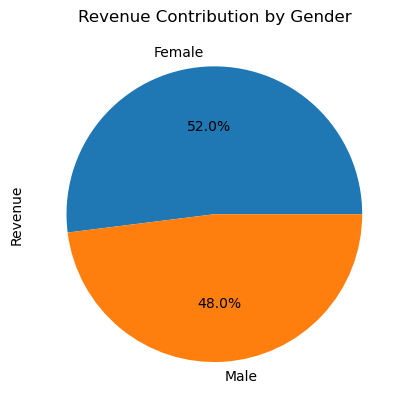

In [25]:
df.groupby('Gender')['Revenue'].sum().plot.pie(autopct='%1.1f%%')
plt.title('Revenue Contribution by Gender')
plt.show()

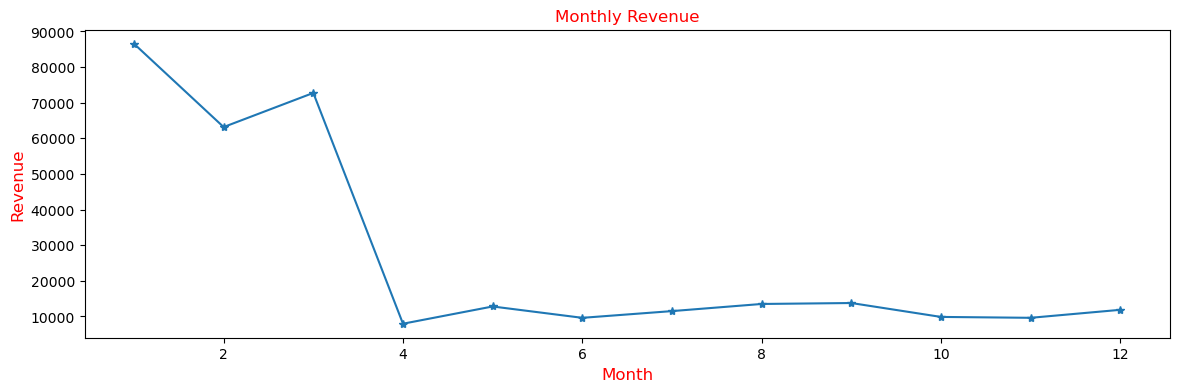

In [26]:
plt.figure(figsize=(14,4))
df.groupby('Month')['Revenue'].sum().plot(marker='*')
plt.title('Monthly Revenue',color='r')
plt.xlabel('Month',color='r',fontsize=12)
plt.ylabel('Revenue',color='r',fontsize=12)
plt.show()

<function matplotlib.pyplot.show(close=None, block=None)>

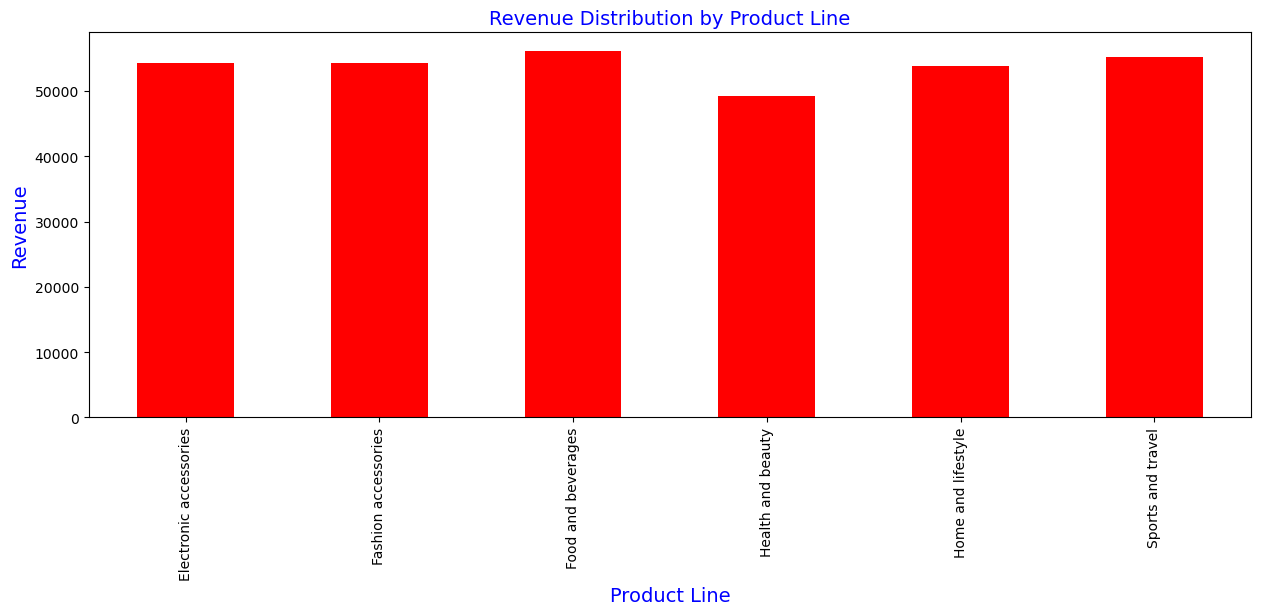

In [27]:
plt.figure(figsize=(15,5))
df.groupby('Product line')['Revenue'].sum().plot.bar(color='r')
plt.title('Revenue Distribution by Product Line',color='b',fontsize=14)
plt.xlabel('Product Line',color='b',fontsize=14)
plt.ylabel('Revenue',color='b',fontsize=14)
plt.show

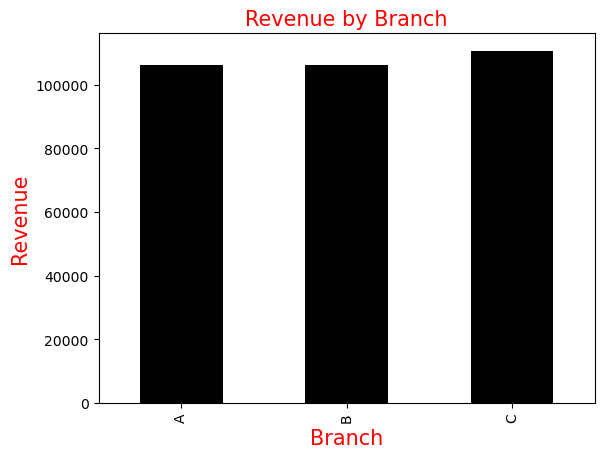

In [28]:
df.groupby('Branch')['Revenue'].sum().plot.bar(color='black')
plt.title('Revenue by Branch',color='r',fontsize=15)
plt.xlabel('Branch',color='r',fontsize=15)
plt.ylabel('Revenue',color='r',fontsize=15)
plt.show()

In [29]:
df.to_csv("C:/Users/gajra/Downloads/cleaned_data.csv", index=False)

* Data analysis shows no strong growth trend, sales stabilize after early drop
* Revenue distribution indicates product concentration dependency
* Customer ratings are consistent but average, suggesting improvement opportunity
* Branch and city analysis show uniform performance with minor variations
* Overall business performance is stable but lacks growth momentum